# Visualize a section of a recording

Load a continuous (or trial) HDF5 recording and plot a time window of
membrane potential (`ScAmpOut`, mV) above command current (`AmpCmd`, pA).
Stimulus apply/clear events are marked when present.

In [1]:
import sys
from collections import defaultdict
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use(PROJECT_ROOT / "analysis" / "kt.mplstyle")

In [40]:
# ── File and time window ──
H5_PATH = Path(r"D:\data\fre033\fre033_ss44039-gfp_20260508_111657.h5")

T_START_S = 7.8  # window start (seconds from recording start)
T_END_S   = 8.3   # window end   (seconds from recording start)
# H5_PATH = Path(r"D:\data\fre032\fre032_ss31541-gfp_20260507_161315.h5")

# T_START_S = 72.5  # window start (seconds from recording start)
# T_END_S   = 73.3  # window end   (seconds from recording start)
# VM_CH  = 0   # ScAmpOut
# CMD_CH = 2   # AmpCmd

SHOW_STIM_EVENTS = True  # mark apply/clear events that fall in the window

In [41]:
with h5py.File(H5_PATH, "r") as f:
    sample_rate    = int(f["metadata"].attrs["sample_rate"])
    channel_names  = [s.decode() if isinstance(s, bytes) else s
                      for s in f["metadata/channel_names"][:]]
    display_scales = f["metadata/display_scales"][:]
    units          = [s.decode() if isinstance(s, bytes) else s
                      for s in f["metadata/units"][:]]

    trial_keys = sorted(k for k in f.keys() if k.startswith("trial_"))
    if trial_keys:
        # Trial-based: concatenate the first stimulus group end-to-end so the
        # time axis is contiguous within that group.
        sweeps_by_name = defaultdict(list)
        for key in trial_keys:
            grp = f[key]
            sweeps_by_name[grp.attrs["stimulus_name"]].append(grp["analog_input"][:])
        first_name = next(iter(sweeps_by_name))
        recording = np.concatenate(sweeps_by_name[first_name], axis=1)
        stimulus_events = None
        print(f"Trial file: using stimulus '{first_name}' "
              f"({len(sweeps_by_name[first_name])} trials concatenated)")
    else:
        recording = f["data/analog_input"][:]
        if "stimulus_events" in f:
            ev = f["stimulus_events"]
            stimulus_events = {
                "sample_index": ev["sample_index"][:],
                "event_type":   [s.decode() if isinstance(s, bytes) else s
                                 for s in ev["event_type"][:]],
                "stimulus_name":[s.decode() if isinstance(s, bytes) else s
                                 for s in ev["stimulus_name"][:]],
            }
        else:
            stimulus_events = None

duration_s = recording.shape[1] / sample_rate
print(f"Sample rate: {sample_rate} Hz  |  duration: {duration_s:.2f} s")
print(f"Channels: {channel_names}")

Sample rate: 20000 Hz  |  duration: 44.76 s
Channels: ['ScAmpOut', 'RawAmpOut', 'AmpCmd', 'Camera', 'TTLLoopback']


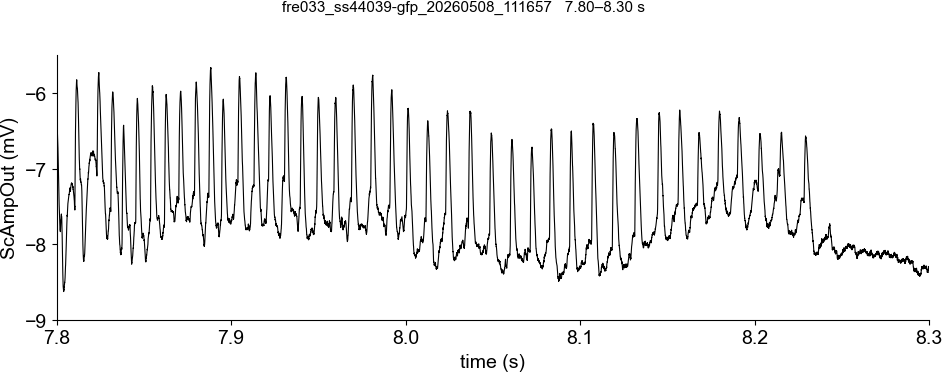

In [42]:
# Slice the requested window
i0 = max(0, int(T_START_S * sample_rate))
i1 = min(recording.shape[1], int(T_END_S * sample_rate))
if i1 <= i0:
    raise ValueError(f"Empty window: T_START_S={T_START_S}, T_END_S={T_END_S}, "
                     f"recording duration={duration_s:.2f}s")

t_s  = np.arange(i0, i1) / sample_rate
vm   = recording[VM_CH,  i0:i1] * display_scales[VM_CH]
icmd = recording[CMD_CH, i0:i1] * display_scales[CMD_CH]

# fig, (ax_vm, ax_cmd) = plt.subplots(
#     2, 1, figsize=(10, 5), sharex=True,
#     gridspec_kw={"height_ratios": [3, 1], "hspace": 0.1},
# )

# ax_vm.plot(t_s, vm, color="black", linewidth=0.8)
# ax_vm.set_ylabel(f"{channel_names[VM_CH]} ({units[VM_CH]})")

# ax_cmd.plot(t_s, icmd, color=(0.15, 0.45, 0.85), linewidth=0.8)
# ax_cmd.set_ylabel(f"{channel_names[CMD_CH]} ({units[CMD_CH]})")
# ax_cmd.set_xlabel("time (s)")

fig, ax_vm = plt.subplots(
    1, 1, figsize=(10, 4),
)

ax_vm.plot(t_s, vm, color="black", linewidth=0.8)
ax_vm.set_ylabel(f"{channel_names[VM_CH]} ({units[VM_CH]})")
ax_vm.set_xlabel("time (s)")

# Overlay stimulus events that fall within the window
if SHOW_STIM_EVENTS and stimulus_events is not None:
    for samp, etype, sname in zip(stimulus_events["sample_index"],
                                  stimulus_events["event_type"],
                                  stimulus_events["stimulus_name"]):
        if not (i0 <= samp < i1):
            continue
        t_ev = samp / sample_rate
        color = "tab:green" if etype == "apply" else "tab:red"
        for ax in (ax_vm, ax_cmd):
            ax.axvline(t_ev, color=color, linewidth=0.8, alpha=0.6, linestyle="--")
        ax_vm.text(t_ev, ax_vm.get_ylim()[1], f" {etype}: {sname}",
                   color=color, fontsize=8, va="top", ha="left", rotation=90)

ax_vm.set_xlim(T_START_S, T_END_S)
fig.suptitle(f"{H5_PATH.stem}   {T_START_S:.2f}–{T_END_S:.2f} s", fontsize=11)
fig.tight_layout()
plt.show()

FFT peak frequency (>= 20 Hz) : 84.00 Hz
Peak-interval frequency           : 95.79 Hz  (n=41 peaks)


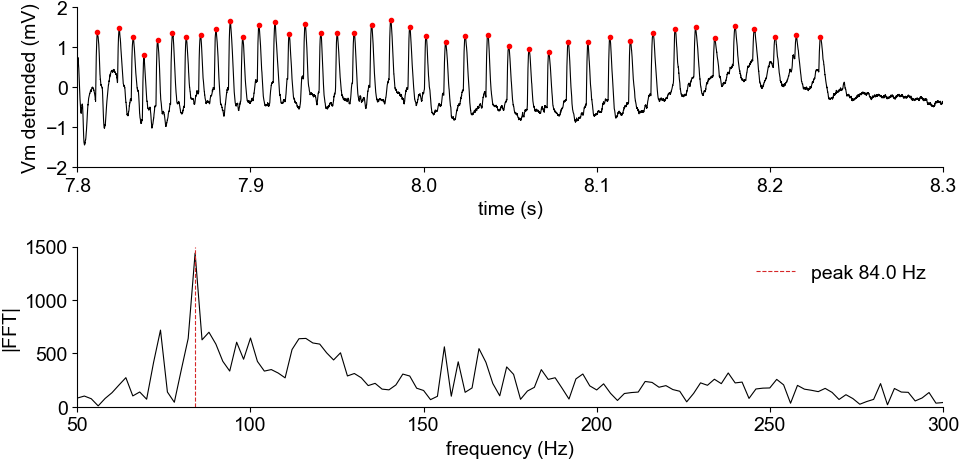

In [43]:
# ── Estimate oscillation frequency in the current window ──
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks, detrend

F_MIN = 20.0  # Hz — ignore spectrum bins below this when picking the FFT peak

vm_d = detrend(vm)  # remove DC + linear trend so the FFT peak isn't at 0 Hz

# Frequency domain: peak of the magnitude spectrum above F_MIN
freqs = rfftfreq(vm_d.size, d=1 / sample_rate)
spec  = np.abs(rfft(vm_d))
band  = freqs >= F_MIN
f_fft = freqs[band][np.argmax(spec[band])]

# Time domain: mean interval between peaks (require >= 1 ms between peaks)
peaks, _ = find_peaks(vm_d, distance=int(sample_rate * 1e-3), prominence=0.5)
if peaks.size >= 2:
    isi_s = np.diff(peaks) / sample_rate
    f_peaks = 1.0 / isi_s.mean()
    f_peaks_std = isi_s.std() / isi_s.mean()**2  # std of 1/T, first-order
else:
    f_peaks = np.nan
    f_peaks_std = np.nan

print(f"FFT peak frequency (>= {F_MIN:g} Hz) : {f_fft:.2f} Hz")
print(f"Peak-interval frequency           : {f_peaks:.2f} Hz  (n={peaks.size} peaks)")

# Quick visual check: spectrum + detected peaks on the trace
fig, (ax_t, ax_f) = plt.subplots(2, 1, figsize=(10, 5))
ax_t.plot(t_s, vm_d, color="black", linewidth=0.8)
ax_t.plot(t_s[peaks], vm_d[peaks], "ro", markersize=3)
ax_t.set_xlabel("time (s)"); ax_t.set_ylabel("Vm detrended (mV)")
ax_t.set_xlim(T_START_S, T_END_S)

ax_f.plot(freqs, spec, color="black", linewidth=0.8)
# ax_f.axvline(F_MIN, color="grey",    linestyle=":",  linewidth=0.8,
#              label=f"F_MIN = {F_MIN:g} Hz")
ax_f.axvline(f_fft, color="tab:red", linestyle="--", linewidth=0.8,
             label=f"peak {f_fft:.1f} Hz")
ax_f.set_xlabel("frequency (Hz)"); ax_f.set_ylabel("|FFT|")
ax_f.set_xlim(50, min(300, freqs[-1]))
ax_f.legend()
fig.tight_layout()
plt.show()